In [14]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [7]:
from sklearn.datasets import fetch_openml

co2 = fetch_openml(data_id=41187, as_frame = True)
co2.frame.head()

,year,month,day,weight,flag,station,co2
0,1958,3,29,4,0,MLO,316.1
1,1958,4,5,6,0,MLO,317.3
2,1958,4,12,4,0,MLO,317.6
3,1958,4,19,6,0,MLO,317.5
4,1958,4,26,2,0,MLO,316.4


In [12]:
co2_data = pl.DataFrame(co2.frame[['year','month','co2','day']]).select(pl.date('year','month','day'),'co2')
co2_data.head()

date,co2
date,f64
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [13]:
co2_data['date'].min(), co2_data['date'].max()

(datetime.date(1958, 3, 29), datetime.date(2001, 12, 29))

Text(0.5, 1.0, 'raw air samples measurements from the mauna loa observatory')

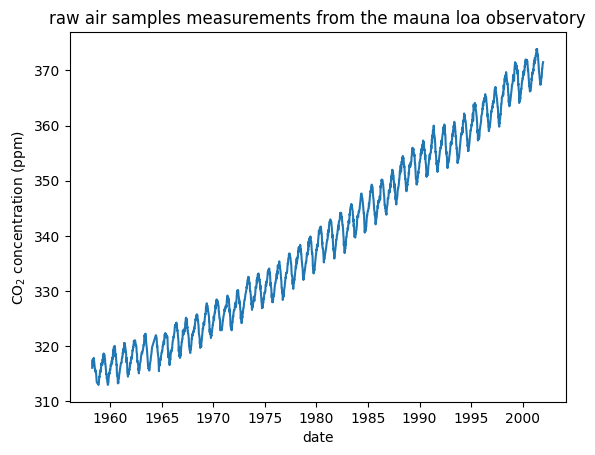

In [16]:
plt.plot(co2_data['date'], co2_data['co2'])
plt.xlabel('date')
plt.ylabel('CO$_2$ concentration (ppm)')
plt.title('raw air samples measurements from the mauna loa observatory')

In [ ]:
co2_data = co2_data.sortby('date').group_by_dynamic('date')